In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

file_path = 'Qwen_ToT_Baseline_vs_CAREDrive.xlsx'
if not os.path.exists(file_path):
    raise FileNotFoundError(f"{file_path} not found in {os.getcwd()}.")

df = pd.read_excel(file_path, sheet_name='LLM Parameter Combinations')

In [2]:
CONDITIONS = [
    ('A_baseline',   'A: Baseline'),
    ('E_care_drive', 'E: Complete\nprompt'),
]
CARE_DRIVE = 'E_care_drive'

# panel A: mean speed offset by condition x rear-vehicle time headway,
# pooled (averaged) across surrounding-traffic speed -- headway shows the
# starker main effect, so it's the panel-A grouping factor.
panel_a = (df.groupby(['Condition', 'Rear_Time_Headway'])['Speed_Offset']
             .agg(mean='mean', n='size').reset_index())

# panel B: the four (headway x traffic-speed) contexts within the complete
# CARE-Drive prompt -- both factors shown in full, nothing pooled away.
CONTEXTS = [
    (1.0, 70, '1.0 s headway /\n70 km/h traffic',  '#9DC3E6', None),
    (1.0, 90, '1.0 s headway /\n90 km/h traffic',  '#E8A33D', '////'),
    (2.5, 70, '2.5 s headway /\n70 km/h traffic',  '#8C8C8C', None),
    (2.5, 90, '2.5 s headway /\n90 km/h traffic',  '#1F4E96', '////'),
]
sub = df[df['Condition'] == CARE_DRIVE]
panel_b = (sub.groupby(['Rear_Time_Headway', 'Surrounding_Traffic_Speed'])['Speed_Offset']
              .agg(mean='mean', n='size').reset_index())

panel_a

,Condition,Rear_Time_Headway,mean,n
0,A_baseline,1.0,1.5,40
1,A_baseline,2.5,1.5,40
2,E_care_drive,1.0,1.5,40
3,E_care_drive,2.5,1.5,40


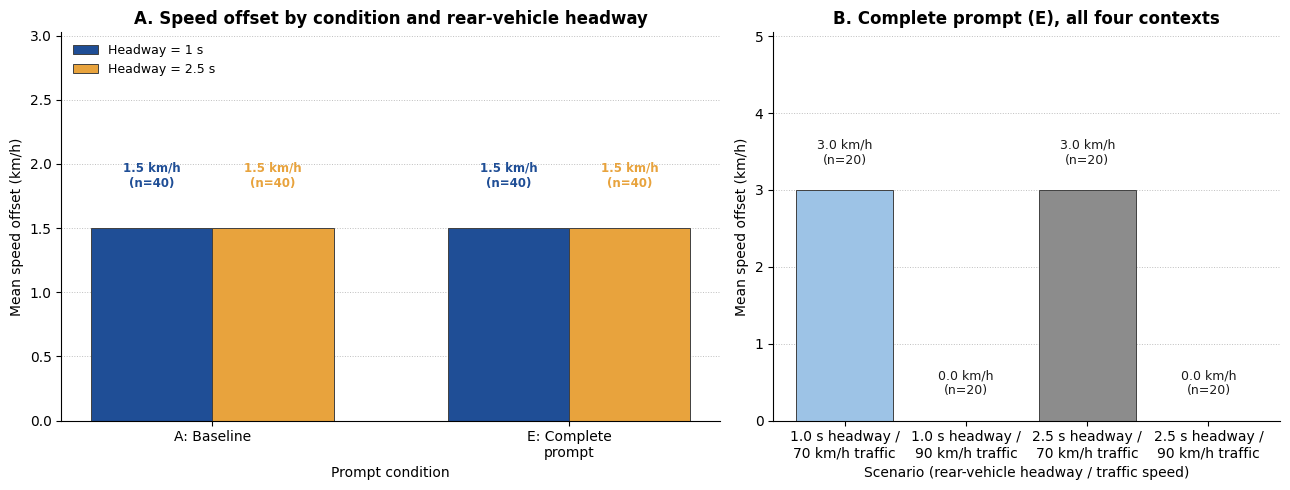

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [1.3, 1]})

HEADWAY_COLORS = {1.0: '#1F4E96', 2.5: '#E8A33D'}

# --- Panel A: grouped bars, one pair (headway 1.0s / 2.5s) per condition ---
headway_values = sorted(panel_a['Rear_Time_Headway'].unique())
x = np.arange(len(CONDITIONS))
width = 0.34

for i, hw in enumerate(headway_values):
    offset = (i - (len(headway_values) - 1) / 2) * width
    rows = [panel_a[(panel_a['Condition'] == key) & (panel_a['Rear_Time_Headway'] == hw)].iloc[0]
            for key, _ in CONDITIONS]
    heights = [r['mean'] for r in rows]

    ax1.bar(x + offset, heights, width=width, color=HEADWAY_COLORS[hw],
            edgecolor='#404040', linewidth=0.7, label=f'Headway = {hw:g} s')

    for xi, h, r in zip(x + offset, heights, rows):
        n = int(r['n'])
        label = f"{h:.1f} km/h\n(n={n})"
        y = 0.3 if h == 0 else h + 0.3
        ax1.text(xi, y, label, ha='center', va='bottom', fontsize=8.5,
                  color=HEADWAY_COLORS[hw], fontweight='bold')

ax1.set_xlabel('Prompt condition')
ax1.set_ylabel('Mean speed offset (km/h)')
ax1.set_xticks(x)
ax1.set_xticklabels([lbl for _, lbl in CONDITIONS])
ax1.set_ylim(0, max(panel_a['mean']) * 1.35 + 1)
ax1.set_title('A. Speed offset by condition and rear-vehicle headway', fontsize=12, fontweight='bold')
ax1.grid(axis='y', linestyle=':', linewidth=0.7, color='#BFBFBF', zorder=0)
ax1.set_axisbelow(True)
ax1.spines[['top', 'right']].set_visible(False)
ax1.legend(frameon=False, fontsize=9, loc='upper left')

# --- Panel B: the four headway x traffic-speed contexts, CARE-Drive only ---
labels = [lbl for _, _, lbl, _, _ in CONTEXTS]
colors = [c for *_, c, _ in CONTEXTS]
hatches = [h for *_, h in CONTEXTS]
values = [panel_b.loc[(panel_b['Rear_Time_Headway'] == hw) & (panel_b['Surrounding_Traffic_Speed'] == sp), 'mean'].iloc[0]
          for hw, sp, _, _, _ in CONTEXTS]

bars = ax2.bar(labels, values, color=colors, edgecolor='#404040', linewidth=0.7)
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

for bar, hw, sp in zip(bars, [c[0] for c in CONTEXTS], [c[1] for c in CONTEXTS]):
    row = panel_b.loc[(panel_b['Rear_Time_Headway'] == hw) & (panel_b['Surrounding_Traffic_Speed'] == sp)].iloc[0]
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
              f"{row['mean']:.1f} km/h\n(n={int(row['n'])})", ha='center', va='bottom',
              fontsize=9, color='#1A1A1A')

ax2.set_xlabel('Scenario (rear-vehicle headway / traffic speed)')
ax2.set_ylabel('Mean speed offset (km/h)')
ax2.set_ylim(0, max(values) * 1.35 + 1)
ax2.set_title('B. Complete prompt (E), all four contexts', fontsize=12, fontweight='bold')
ax2.grid(axis='y', linestyle=':', linewidth=0.7, color='#BFBFBF', zorder=0)
ax2.set_axisbelow(True)
ax2.spines[['top', 'right']].set_visible(False)

fig.tight_layout()

for ext in ('png', 'pdf', 'svg'):
    fig.savefig(f'speed_offset_two_panel.{ext}', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()